αカードは年に4回カードの入会CPを実施している。毎年数ヶ月に一度定期的に開催されることが恒例化している。定期的に開催されているが、毎回CP時には数多くの申し込みがあり、CP期間に申し込みをする人とCP期間外に申し込みをする人で、退会までの日数や利用額に違いがあるのかを検定を実施しその差を図ることとする。

＜検定の流れ＞  
（１）退会について
CP期間中に申し込んだ人とCP期間外に申し込んだ人で、早期退会の早さに差があるかどうか。

（２）利用額について
CP期間中に申し込んだ人とCP期間外に申し込んだ人で、本カードの利用額に差があるかどうか。  
→①本カードの利用有無（一度でも利用するか否か）に差があるかどうか。  
→②本カードを一度でも利用した人について、利用額に差があるかどうか。

In [46]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
sns.set_theme

<function seaborn.rcmod.set_theme(context='notebook', style='darkgrid', palette='deep', font='sans-serif', font_scale=1, color_codes=True, rc=None)>

（１）退会について  
CP期間中に申し込んだ人とCP期間外に申し込んだ人について、退会までの早さに差があるかを検証。

In [47]:
#CSVファイルの読み込み・内容の確認（入会・退会に関するデータ）
#withdrawal_days:20XX年度にαカードを申し込んだ人の本カード発行から退会までの日数。（本カード発行済の人のデータのみ。申込経路は統一。データ抽出時点で未退会の人は欠損値。）
#count:20XX年度にαカードを申し込んだ人のうち、20XX年度~20XX+1年度の2年間でαカードを申し込んだ回数。（申込経路は統一。本検定では分析対象外。）
data0=pd.read_csv("nyuutaikai.csv")
data0.head()

,No,card,age,sex,withdrawal_days,count,CP
0,1,B,59,1,231,1,1
1,2,B,51,1,#VALUE!,1,1
2,3,B,78,1,#VALUE!,1,1
3,4,B,47,1,#VALUE!,1,1
4,5,B,57,1,#VALUE!,1,1


In [48]:
#データ全体の概要
data0.describe()

,No,age,sex,count,CP
count,76211.00000,76211.000000,76211.000000,76211.000000,76211.000000
mean,38106.00000,38.898755,0.834027,1.009710,0.583223
std,22000.36502,15.616298,0.372059,0.110278,0.493029
min,1.00000,19.000000,0.000000,1.000000,0.000000
25%,19053.50000,26.000000,1.000000,1.000000,0.000000
50%,38106.00000,33.000000,1.000000,1.000000,1.000000
75%,57158.50000,51.000000,1.000000,1.000000,1.000000
max,76211.00000,98.000000,1.000000,5.000000,1.000000


In [49]:
#欠損値の確認
print(data0.isnull().sum())

No                 0
card               0
age                0
sex                0
withdrawal_days    0
count              0
CP                 0
dtype: int64


In [50]:
#withdrawal_days列について、#VALUE!	エラーをNaNに置き換え
data0["withdrawal_days"]=data0["withdrawal_days"].replace("#VALUE!",np.nan).astype(float)

In [51]:
data0

,No,card,age,sex,withdrawal_days,count,CP
0,1,B,59,1,231.0,1,1
1,2,B,51,1,NaN,1,1
2,3,B,78,1,NaN,1,1
3,4,B,47,1,NaN,1,1
4,5,B,57,1,NaN,1,1
...,...,...,...,...,...,...,...
76206,76207,A,38,0,NaN,1,0
76207,76208,A,21,0,109.0,1,0
76208,76209,A,25,1,NaN,1,0
76209,76210,A,21,1,NaN,1,0


仮説1_1：CP期間中に申し込んだ人とCP期間外に申し込んだ人とでは、退会までの早さに差がある。

In [ ]:
#退会までの日数から、①180日（半年）以内退会：1、③181日〜365日（半年〜1年）以内退会：2、④366日（1年）以上継続：3と分類するための列を追加。
data0["taikai"]=1
data0.loc[data0["withdrawal_days"].between(181,365),"taikai"]=2
data0.loc[(data0["withdrawal_days"]>=366)|(data0["withdrawal_days"].isna()),"taikai"]=3
data0

,No,card,age,sex,withdrawal_days,count,CP,taikai
0,1,B,59,1,231.0,1,1,2
1,2,B,51,1,NaN,1,1,3
2,3,B,78,1,NaN,1,1,3
3,4,B,47,1,NaN,1,1,3
4,5,B,57,1,NaN,1,1,3
...,...,...,...,...,...,...,...,...
76206,76207,A,38,0,NaN,1,0,3
76207,76208,A,21,0,109.0,1,0,1
76208,76209,A,25,1,NaN,1,0,3
76209,76210,A,21,1,NaN,1,0,3


In [63]:
#連続値として認識されないよう、"sex","CP"列をそれぞれ文字列に変換
data0["sex"]=data0["sex"].astype(str)
data0["CP"]=data0["CP"].astype(str)

In [ ]:
#CP期間中に申し込んだ人、CP期間外に申し込んだ人でそれぞれデータを抽出
data0_CP=data0.query("CP=='1'")
data0_CP["taikai"]=data0_CP["taikai"].astype(str)
data0_notCP=data0.query("CP=='0'")
data0_notCP["taikai"]=data0_notCP["taikai"].astype(str)


/var/folders/cx/jds9b3yn25bbfv_r9qtyy0y00000gp/T/ipykernel_1380/707704471.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data0_CP["taikai"]=data0_CP["taikai"].astype(str)
/var/folders/cx/jds9b3yn25bbfv_r9qtyy0y00000gp/T/ipykernel_1380/707704471.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data0_notCP["taikai"]=data0_notCP["taikai"].astype(str)


Text(0.5, 1.0, 'NOT_CP')

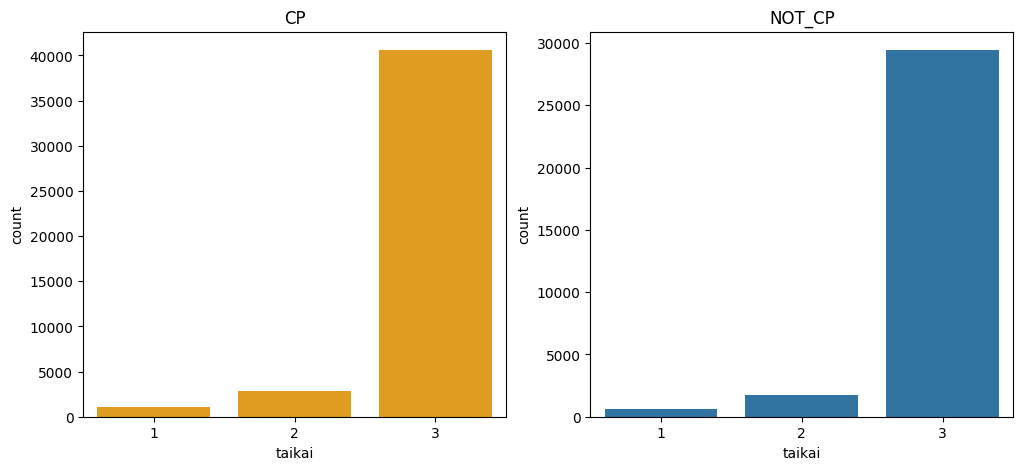

In [ ]:
#早期退会フラグに関する内訳を描画
fig,axes=plt.subplots(1,2,figsize=(12,5))

#CP期間中に申し込んだ人のCPフラグの内訳
order=["1","2","3"]
sns.countplot(x="taikai",data=data0_CP,order=order,ax=axes[0],color="orange")
axes[0].set_title("CP")

#CP期間外に申し込んだ人のCPフラグの内訳
order=["1","2","3"]
sns.countplot(x="taikai",data=data0_notCP,order=order,ax=axes[1])
axes[1].set_title("NOT_CP")

In [11]:
#一元分散分析を実施（説明変数：CPフラグ）
anova_model1_1=smf.ols("taikai~CP",data=data0).fit()
sm.stats.anova_lm(anova_model1_1,typ=2)

,sum_sq,df,F,PR(>F)
CP,7.208976,1.0,40.371546,2.111576e-10
Residual,13608.318966,76209.0,NaN,NaN


In [12]:
#二元分散分析を実施（説明変数：CPフラグ、性別）
anova_model1_2=smf.ols("taikai~CP+sex",data=data0).fit()
sm.stats.anova_lm(anova_model1_2,typ=2)

,sum_sq,df,F,PR(>F)
CP,7.205824,1.0,40.414193,2.066008e-10
sex,20.483539,1.0,114.882870,8.724148e-27
Residual,13587.835427,76208.0,NaN,NaN


In [13]:
#二元分散分析を実施（説明変数：CPフラグ、性別、年齢）
anova_model1_3=smf.ols("taikai~CP+sex+age",data=data0).fit()
sm.stats.anova_lm(anova_model1_3,typ=2)

,sum_sq,df,F,PR(>F)
CP,7.554567,1.0,42.453067,7.284802e-11
sex,17.862883,1.0,100.380898,1.300420e-23
age,26.721886,1.0,150.164276,1.720138e-34
Residual,13561.113541,76207.0,NaN,NaN


In [14]:
#二元分散分析を実施（説明変数：CPフラグ、性別、年齢、カード種別）
anova_model1_4=smf.ols("taikai~CP+sex+age+card",data=data0).fit()
sm.stats.anova_lm(anova_model1_4,typ=2)

,sum_sq,df,F,PR(>F)
CP,6.850802,1.0,38.502808,5.495514e-10
sex,17.914929,1.0,100.685299,1.115391e-23
card,1.962483,2.0,5.514764,4.028484e-03
age,26.481503,1.0,148.831068,3.360529e-34
Residual,13559.151057,76205.0,NaN,NaN


In [15]:
#AICで比較
print("anova_model1_1:",anova_model1_1.aic)
print("anova_model1_2:",anova_model1_2.aic)
print("anova_model1_3:",anova_model1_3.aic)
print("anova_model1_4:",anova_model1_4.aic)

anova_model1_1: 84983.27000883603
anova_model1_2: 84870.46912539453
anova_model1_3: 84722.44472863706
anova_model1_4: 84715.41512987841


仮説1_1に対する結果の解釈:  
AICが最も小さいmodel1_4を採用。CPのP値が0.05を下回っており有意であることから、CP期間中に申し込んだ人とCP期間外に申し込んだ人とでは退会までの早さに差が見られる。

仮説1_2 CP期間中に申し込んだ人は、CP期間外に申し込んだ人に比べて半年及び1年以内に退会する傾向が強い。

In [76]:
#退会までの日数から、①180日（半年）以内退会フラグ、②365日（1年）以内退会フラグを立てる。
data0["flag180"]=(data0["withdrawal_days"]<=180).astype(int)
data0["flag365"]=(data0["withdrawal_days"]<=365).astype(int)
data0

,No,card,age,sex,withdrawal_days,count,CP,taikai,flag180,flag365
0,1,B,59,1,231.0,1,1,2,0,1
1,2,B,51,1,NaN,1,1,3,0,0
2,3,B,78,1,NaN,1,1,3,0,0
3,4,B,47,1,NaN,1,1,3,0,0
4,5,B,57,1,NaN,1,1,3,0,0
...,...,...,...,...,...,...,...,...,...,...
76206,76207,A,38,0,NaN,1,0,3,0,0
76207,76208,A,21,0,109.0,1,0,1,1,1
76208,76209,A,25,1,NaN,1,0,3,0,0
76209,76210,A,21,1,NaN,1,0,3,0,0


In [77]:
#カテゴリ値のダミー変数化
data0_dummied=pd.get_dummies(data0)
data0_dummied.head()

,No,age,withdrawal_days,count,taikai,flag180,flag365,card_A,card_B,card_R,sex_0,sex_1,CP_0,CP_1
0,1,59,231.0,1,2,0,1,False,True,False,False,True,False,True
1,2,51,NaN,1,3,0,0,False,True,False,False,True,False,True
2,3,78,NaN,1,3,0,0,False,True,False,False,True,False,True
3,4,47,NaN,1,3,0,0,False,True,False,False,True,False,True
4,5,57,NaN,1,3,0,0,False,True,False,False,True,False,True


仮説1_2_1 CP期間中に申し込んだ人は、CP期間外に申し込んだ人に比べて半年以内に退会する傾向が強い。

In [78]:
#説明変数：CP期間内か否か、性別、年齢、カード種別で一般化線形モデルを作成
model180=smf.glm('flag180~CP_1+age+sex_1+card_A+card_B',data=data0_dummied,family=sm.families.Binomial()).fit()

In [79]:
print(model180.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                flag180   No. Observations:                76211
Model:                            GLM   Df Residuals:                    76205
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7718.0
Date:                Wed, 22 Apr 2026   Deviance:                       15436.
Time:                        11:57:59   Pearson chi2:                 7.60e+04
No. Iterations:                     7   Pseudo R-squ. (CS):           0.002330
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -4.0632      0.102    -39.

仮説1_2_2 CP期間中に申し込んだ人は、CP期間外に申し込んだ人に比べて1年以内に退会する傾向が強い。

In [80]:
#説明変数：CP期間内か否か、性別、年齢、カード種別で一般化線形モデルを作成
model365=smf.glm('flag365~CP_1+age+sex_1+card_A+card_B',data=data0_dummied,family=sm.families.Binomial()).fit()

In [81]:
print(model365.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                flag365   No. Observations:                76211
Model:                            GLM   Df Residuals:                    76205
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -21309.
Date:                Wed, 22 Apr 2026   Deviance:                       42618.
Time:                        12:02:02   Pearson chi2:                 7.62e+04
No. Iterations:                     6   Pseudo R-squ. (CS):           0.003696
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -2.7613      0.055    -49.

仮説1_2に対する結果の解釈:  
180日以内退会フラグ及び365日以内退会フラグ双方に対して、CPフラグのP値が0.05を下回り係数が正の値を取っている。  
一方で、決定係数が非常に小さくモデルとしての当てはまりが良くない。  
→CP期間中の申込者はCP期間外の申込者に比べて早期退会する傾向が強い可能性が示唆されたが、本モデルでは因果的関係などそれ以上の安定した解釈を得ることはできない。

（2）利用額について  
CP期間中に申し込んだ人とCP期間外に申し込んだ人について、本カードの利用額に差があるかどうかを検証。

In [16]:
#CSVファイルの読み込み・内容の確認（利用に関するデータ）
#ファイルはCP実施月ごとに４つのフォルダに分かれており、CP期間中とCP期間外の申し込みが判別できるようCPフラグを立てている。
#本データはCP実施月のみを対象としているため、CP未実施月の情報は含まれていない。
data1=pd.read_csv("riyou1.csv")
data2=pd.read_csv("riyou2.csv")
data3=pd.read_csv("riyou3.csv")
data4=pd.read_csv("riyou4.csv")

In [17]:
#CP実施月のカラムを追加
data1["month"]="1"
data2["month"]="2"
data3["month"]="3"
data4["month"]="4"

In [18]:
#データを1つにまとめる　#Noカラムの削除
#90days:本カードにおける発行後90日間の利用額。本カード発行日から起算。
#14days:短期カードにおける発行後14日間の利用額。短期カード発行日から起算。本検定では分析対象外とする。
data5=pd.concat([data1,data2,data3,data4])
data5=data5.drop(columns="No")
data5

,card,credit1,credit2,work,age,sex,90days,14days,CP,month
0,A,800000,300000,7,61,1,0.0,63065,1,1
1,A,1800000,1800000,4,59,1,34137.0,97397,1,1
2,A,800000,800000,12,77,1,0.0,33023,1,1
3,A,1200000,1200000,8,66,1,69692.0,41773,1,1
4,A,1300000,1300000,2,52,0,1280.0,66524,1,1
...,...,...,...,...,...,...,...,...,...,...
11744,A,700000,700000,2,29,0,0.0,35103,0,4
11745,A,600000,600000,2,28,0,117860.0,77425,0,4
11746,A,200000,200000,6,21,1,3000.0,11681,0,4
11747,A,200000,200000,2,26,0,0.0,23310,0,4


In [19]:
#データ全体の概要
data5.describe()

,credit1,credit2,work,age,sex,90days,14days,CP
count,4.269200e+04,4.269200e+04,42692.000000,42692.000000,42692.000000,3.932400e+04,42692.000000,42692.000000
mean,7.449557e+05,6.373068e+05,3.727513,38.394008,0.851003,7.197850e+04,35788.890354,0.878736
std,2.977336e+05,3.192847e+05,2.507159,15.018266,0.356090,4.049257e+05,39574.559315,0.326438
min,5.000000e+04,0.000000e+00,1.000000,19.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,5.000000e+05,3.000000e+05,2.000000,26.000000,1.000000,1.000000e+04,11082.750000,1.000000
50%,7.000000e+05,6.000000e+05,2.000000,33.000000,1.000000,3.452750e+04,23191.500000,1.000000
75%,1.000000e+06,9.000000e+05,6.000000,50.000000,1.000000,8.492150e+04,45429.750000,1.000000
max,2.000000e+06,1.800000e+06,13.000000,97.000000,1.000000,7.699478e+07,720000.000000,1.000000


In [20]:
#欠損値の確認
print(data5.isnull().sum())

card          0
credit1       0
credit2       0
work          0
age           0
sex           0
90days     3368
14days        0
CP            0
month         0
dtype: int64


In [21]:
#90days列の欠損値は全て「0円」であるため欠損値に0を補完
data5=data5.fillna(0)

In [22]:
#CP期間中/CP期間外申込者で分けたDataFrameを用意
data5_cp=data5.query("CP==1")
data5_notcp=data5.query("CP==0")

<Axes: xlabel='month', ylabel='90days'>

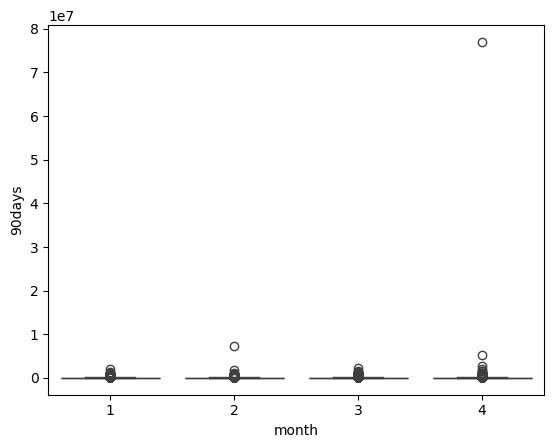

In [23]:
#本カード発行日から90日間の本カード利用額について、CP実施月（申込月）ごとの分布を確認
sns.boxplot(x="month",y="90days",data=data5)

<Axes: xlabel='month', ylabel='90days'>

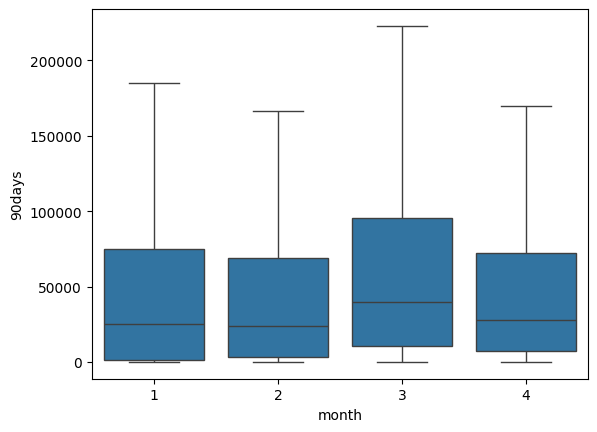

In [24]:
#外れ値の非表示
sns.boxplot(x="month",y="90days",data=data5,showfliers=False)

<Axes: xlabel='CP', ylabel='90days'>

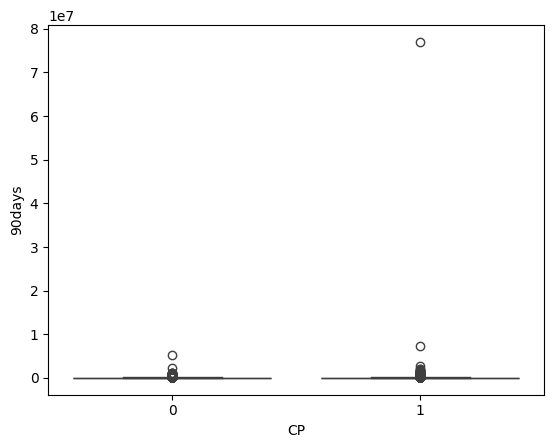

In [25]:
#本カード発行日から90日間の本カード利用額について、CP期間中/CP期間外申込者ごとの分布を確認
sns.boxplot(x="CP",y="90days",data=data5)

<Axes: xlabel='CP', ylabel='90days'>

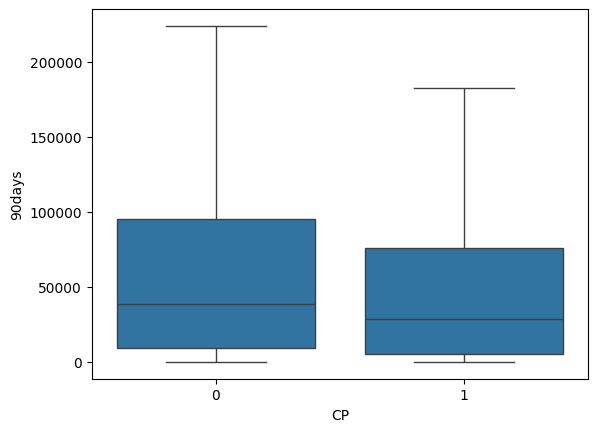

In [26]:
#外れ値の非表示
sns.boxplot(x="CP",y="90days",data=data5,showfliers=False)

仮説2：CP期間中に申し込んだか否かは、本カード発行後90日間における利用有無に影響を与える。

In [27]:
#本カード発行後90日間におけるカード利用について、利用有無フラグを立てる（利用額０円とそれ以外で分ける）
data5["riyouumu90"]=(data5["90days"]>0).astype(str)

<Axes: xlabel='riyouumu90', ylabel='count'>

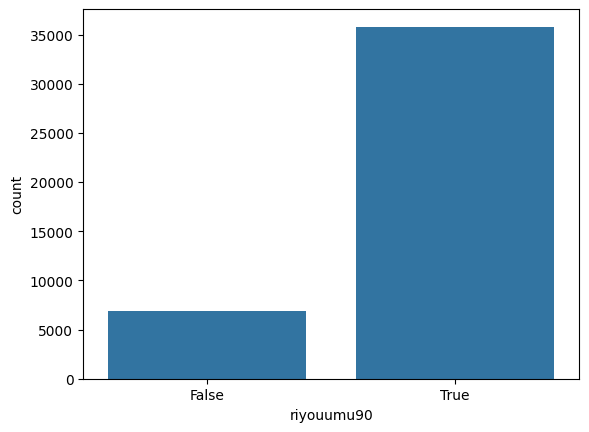

In [29]:
#本カード発行後90日以内における利用有無の割合（True:利用あり,False:利用なし）
sns.countplot(x="riyouumu90",data=data5)

In [331]:
#連続値として認識されないよう、"sex","CP"列をカテゴリ値に置き換え(適切にダミー変数化が行われるよう調整)
data5["sex"]=data5["sex"].astype(str)
data5["CP"]=data5["CP"].astype(str)

In [332]:
#利用有無フラグをint型に変換（一般化線形モデル作成のため）
data5["riyouumu90"]=(data5["90days"]>0).astype(int)

In [333]:
#カテゴリ値のダミー変数化
data5_dummied=pd.get_dummies(data5)
data5_dummied.head()

,credit1,credit2,work,age,90days,14days,riyouumu90,card_A,card_B,card_R,sex_0,sex_1,CP_0,CP_1,month_1,month_2,month_3,month_4
0,800000,300000,7,61,0.0,63065,0,True,False,False,False,True,False,True,True,False,False,False
1,1800000,1800000,4,59,34137.0,97397,1,True,False,False,False,True,False,True,True,False,False,False
2,800000,800000,12,77,0.0,33023,0,True,False,False,False,True,False,True,True,False,False,False
3,1200000,1200000,8,66,69692.0,41773,1,True,False,False,False,True,False,True,True,False,False,False
4,1300000,1300000,2,52,1280.0,66524,1,True,False,False,True,False,False,True,True,False,False,False


In [334]:
#説明変数：CP期間内か否かのみで一般化線形モデルを作成
model2_1=smf.glm('riyouumu90~CP_1',data=data5_dummied,family=sm.families.Binomial()).fit()

In [335]:
print(model2_1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             riyouumu90   No. Observations:                42692
Model:                            GLM   Df Residuals:                    42690
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -18832.
Date:                Tue, 21 Apr 2026   Deviance:                       37664.
Time:                        19:48:10   Pearson chi2:                 4.27e+04
No. Iterations:                     5   Pseudo R-squ. (CS):           0.001394
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.9426      0.042     46.283   

In [336]:
#説明変数：CP期間内か否か＋性別で一般化線形モデルを作成
model2_2=smf.glm('riyouumu90~CP_1+sex_1',data=data5_dummied,family=sm.families.Binomial()).fit()

In [337]:
print(model2_2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             riyouumu90   No. Observations:                42692
Model:                            GLM   Df Residuals:                    42689
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -18805.
Date:                Tue, 21 Apr 2026   Deviance:                       37609.
Time:                        19:48:13   Pearson chi2:                 4.27e+04
No. Iterations:                     5   Pseudo R-squ. (CS):           0.002678
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.7188      0.051     33.598

In [338]:
#説明変数：CP期間内か否か＋性別＋年齢で一般化線形モデルを作成
model2_3=smf.glm('riyouumu90~CP_1+sex_1+age',data=data5_dummied,family=sm.families.Binomial()).fit()

In [339]:
print(model2_3.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             riyouumu90   No. Observations:                42692
Model:                            GLM   Df Residuals:                    42688
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -18797.
Date:                Tue, 21 Apr 2026   Deviance:                       37595.
Time:                        19:48:17   Pearson chi2:                 4.27e+04
No. Iterations:                     5   Pseudo R-squ. (CS):           0.003009
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.8512      0.062     29.801

In [340]:
#説明変数：CP期間内か否か＋性別＋年齢+限度額で一般化線形モデルを作成
model2_4=smf.glm('riyouumu90~CP_1+sex_1+age+credit1',data=data5_dummied,family=sm.families.Binomial()).fit()

In [341]:
print(model2_4.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             riyouumu90   No. Observations:                42692
Model:                            GLM   Df Residuals:                    42687
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -18696.
Date:                Tue, 21 Apr 2026   Deviance:                       37391.
Time:                        19:48:20   Pearson chi2:                 4.26e+04
No. Iterations:                     5   Pseudo R-squ. (CS):           0.007756
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.5103      0.066     22.856

In [342]:
#説明変数：CP期間内か否か＋性別＋年齢+限度額+カード種別で一般化線形モデルを作成
model2_5=smf.glm('riyouumu90~CP_1+sex_1+age+credit1+card_A+card_B',data=data5_dummied,family=sm.families.Binomial()).fit()

In [343]:
print(model2_5.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             riyouumu90   No. Observations:                42692
Model:                            GLM   Df Residuals:                    42685
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -18548.
Date:                Tue, 21 Apr 2026   Deviance:                       37096.
Time:                        19:48:23   Pearson chi2:                 4.27e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.01459
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.8513      0.070     26.

In [344]:
#AICで比較
print("model2_1:",model2_1.aic)
print("model2_2:",model2_2.aic)
print("model2_3:",model2_3.aic)
print("model2_4:",model2_4.aic)
print("model2_5:",model2_5.aic)

model2_1: 37668.03799493565
model2_2: 37615.10631208525
model2_3: 37602.91412519116
model2_4: 37401.16963998029
model2_5: 37110.300853587556


仮説2に対する結果の解釈:  
AICが最も小さいmodel2_5を採用。CPフラグのP値が0.05を下回っており有意であることから、CP期間中に申し込んだか否かは本カード発行後90日間における利用有無に影響を与える。CP期間中に申し込んだ人は、CP期間外に申し込んだ人に比べて本カード発行後90日間において利用しない傾向が高い。

仮説3:CP期間中に申し込んだ人とCP期間外に申し込んだ人とでは、本カード発行後90日間における利用額に差がある。  
※一度も利用していない人（利用額0円）を除き、90日間のうちに一度でも利用した人の利用額を対象とする。

In [345]:
#本カード発行後90日間で一度でも利用ありの人を抽出（利用額0円の人を除外）
data5_90riyouari=data5.query("riyouumu90==1")

In [346]:
data5_90riyouari

,card,credit1,credit2,work,age,sex,90days,14days,CP,month,riyouumu90
1,A,1800000,1800000,4,59,1,34137.0,97397,1,1,1
3,A,1200000,1200000,8,66,1,69692.0,41773,1,1,1
4,A,1300000,1300000,2,52,0,1280.0,66524,1,1,1
5,A,1300000,300000,7,56,1,84364.0,5596,1,1,1
6,A,700000,700000,1,71,1,14471.0,6738,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
11742,A,700000,700000,2,30,0,28689.0,109820,0,4,1
11743,R,700000,700000,2,32,1,326430.0,10450,0,4,1
11745,A,600000,600000,2,28,0,117860.0,77425,0,4,1
11746,A,200000,200000,6,21,1,3000.0,11681,0,4,1


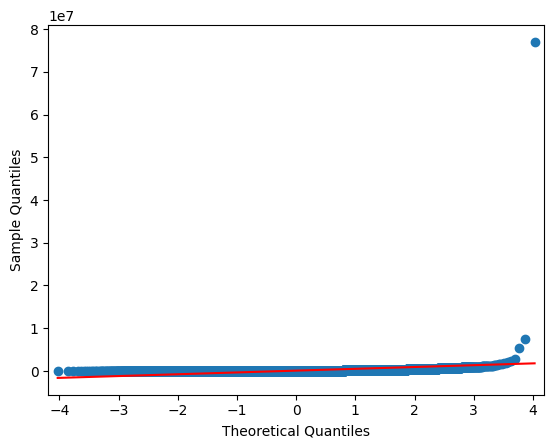

In [347]:
#正規性の確認（本カードにおける発行後90日間の利用額）
fig_90=sm.qqplot(data5_90riyouari["90days"],line="s")

In [348]:
#対数変換
data5_90riyouari["90days"]=np.log1p(data5_90riyouari["90days"])

/var/folders/cx/jds9b3yn25bbfv_r9qtyy0y00000gp/T/ipykernel_834/2718999111.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data5_90riyouari["90days"]=np.log1p(data5_90riyouari["90days"])


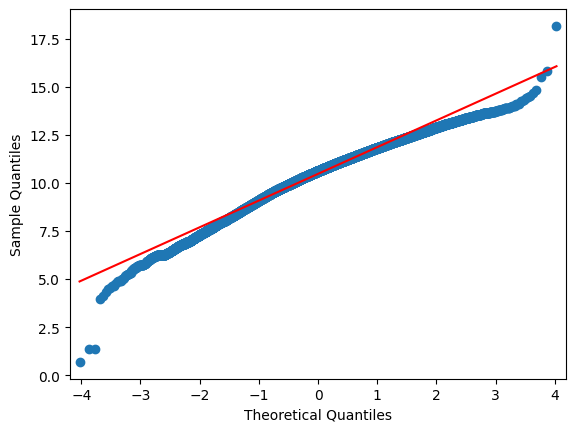

In [349]:
#対数変換後の正規性の確認
fig_90=sm.qqplot(data5_90riyouari["90days"],line="s")

<Axes: xlabel='CP', ylabel='90days'>

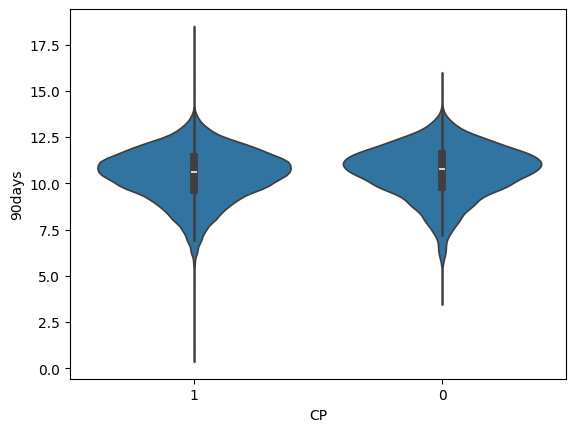

In [350]:
#対数変換後の分布の確認
sns.violinplot(x="CP",y="90days",data=data5_90riyouari)

In [351]:
#T検定のため、データをCPフラグの有無で分けてそれぞれの本カードにおける90日間利用額を抜き出す
group_cp90=data5_90riyouari[data5_90riyouari["CP"]=="1"]["90days"]
group_notcp90=data5_90riyouari[data5_90riyouari["CP"]=="0"]["90days"]

In [352]:
#T検定の実施
stats.ttest_ind(group_cp90,group_notcp90,equal_var=False)

TtestResult(statistic=np.float64(-7.757120397356574), pvalue=np.float64(1.0167417886767015e-14), df=np.float64(5906.493299426083))

仮説3に対する結果の解釈:  
P値が0.05を下回ったので有意差がある、つまりCP期間中に申し込んだ人とCP期間外に申し込んだ人では本カード発行後90日間における利用額に差がある。

仮説4：CP実施月は本カード発行後90日間利用額に影響を与える。

In [230]:
#分散分析のため、カラム名を一部変更
data5_90riyouari=data5_90riyouari.rename(columns={"90days":"days90"})

In [232]:
#一元分散分析を実施（説明変数：month）
anova_model4_1=smf.ols("days90~month",data=data5_90riyouari).fit()
sm.stats.anova_lm(anova_model4_1,typ=2)

,sum_sq,df,F,PR(>F)
month,504.164688,3.0,87.82959,1.276537e-56
Residual,68504.263684,35802.0,NaN,NaN


In [233]:
#二元分散分析を実施（説明変数：month、CP）
anova_model4_2=smf.ols("days90~month+CP",data=data5_90riyouari).fit()
sm.stats.anova_lm(anova_model4_2,typ=2)

,sum_sq,df,F,PR(>F)
month,502.892775,3.0,87.752872,1.430422e-56
CP,114.995124,1.0,60.198632,8.802033e-15
Residual,68389.268560,35801.0,NaN,NaN


In [234]:
#二元分散分析を実施（説明変数：month、CP、限度額）
anova_model4_3=smf.ols("days90~month+CP+credit1",data=data5_90riyouari).fit()
sm.stats.anova_lm(anova_model4_3,typ=2)

,sum_sq,df,F,PR(>F)
month,519.077609,3.0,91.172252,8.968021e-59
CP,122.359607,1.0,64.474757,1.007435e-15
credit1,448.354235,1.0,236.250598,3.821431e-53
Residual,67940.914326,35800.0,NaN,NaN


In [235]:
#二元分散分析を実施（説明変数：month、CP、限度額、性別、年齢、カード種別）
anova_model4_4=smf.ols("days90~month+CP+credit1+sex+age+card",data=data5_90riyouari).fit()
sm.stats.anova_lm(anova_model4_4,typ=2)

,sum_sq,df,F,PR(>F)
month,220.214686,3.0,39.069554,3.383907e-25
CP,116.703090,1.0,62.114899,3.331161e-15
sex,4.857248,1.0,2.585257,1.078717e-01
card,10.460148,2.0,2.783693,6.182322e-02
credit1,824.249095,1.0,438.704315,7.908846e-97
age,676.478256,1.0,360.053693,6.771045e-80
Residual,67254.457225,35796.0,NaN,NaN


In [236]:
#AICで比較
print("anova_model4_1:",anova_model_1.aic)
print("anova_model4_2:",anova_model_2.aic)
print("anova_model4_3:",anova_model_3.aic)
print("anova_model4_4:",anova_model_4.aic)

anova_model4_1: 84983.27000883603
anova_model4_2: 84870.46912539453
anova_model4_3: 84722.44472863706
anova_model4_4: 84715.41512987841


仮説4に対する結果の解釈:  
AICが最も小さいmodel4_4を採用。monthのP値が0.05を下回っており有意であることから、申込月は本カード発行後90日間における利用有無に影響を与えるが、F値が小さいため影響力はそれほど大きくない。

＜まとめ＞  
（１）退会について  
　CP期間中に申し込んだ人とCP期間外に申し込んだ人とでは、退会までの日数に差がある。

（２）利用額について  
　①本カード発行後90日間におけるカードの利用有無について（仮説2）  
　CP期間中に申し込んだか否かは本カード発行後90日間における利用有無に影響を与える。  
　CP期間中に申し込んだ人は、CP期間外に申し込んだ人に比べて本カード発行後90日間において利用しない傾向が高い。  
  
　②本カード発行後90日間におけるカードの利用額について（仮説3、4）  
　CP期間中に申し込んだ人とCP期間外に申し込んだ人では、本カード発行後90日間における利用額に差がある。  
　申込月は本カード発行後90日間における利用有無に影響を与えるが、影響力はそれほど大きくない。

